# Immune Cell Classification Report



In [1]:
import random
from collections import Counter
from contextlib import nullcontext
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image as PILImage
from IPython.display import Markdown, display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler, random_split
from torchvision import models, transforms
from tqdm.auto import tqdm

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

PROJECT_ROOT = Path.cwd()
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
SEED = 3888

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

#print(f"Device: {device}")


## Executive Summary

This project developed a machine learning based prototype for classifying immune cells from H&E stained images. The task focused on distinguishing between B-cells, T-cell, and macrophages, which is difficult because these cell types share subtle and overlapping morphological features. The dataset has substantially more T-cell images, so preprocessing and evaluation were designed to account for uneven class representation.

We evaluated five pretrained architectures using transfer learning including ResNet50, DenseNet121, Efficient-NetB0, MobileNetV3-Large, and ViT-B/16. Each model was trained using a consistent two-phase fine-tuning strategy. MobileNet achieved the best overall accuracy, while EfficientNet produced the strongest ROC-AUC, suggesting that different models correctly predicted different aspects of the image data.

To improve robustness, we developed a soft-voting ensemble using EfficientNet and MobileNet. This pair was selected because it combined strong individual performance with relatively low error correlation. The final system was deployed as a Streamlit prototype, allowing users to upload cell images, view predicted classes and confidence scores, and inspect GRAD-Cam visualisations to interpret visual features. The project demonstrates the feasibility of combining transfer learnings within CNN and vision transformers with ensembling for immune cell classification.

## Aim and Background

### Description of the Problem and Motivational Background

Pathology enables the accurate and timely diagnosis of diseases to ensure patients receive the appropriate treatment. However, diagnosis is challenging due to the complexity of diseases, which often share clinical and histological features, and impact patients differently. Moreover, inaccurate diagnoses pose severe consequences for patients [6], further emphasising the need for precise and reliable diagnostic methods.

Since pathology is a broad field, this project focuses on the classification of immune cells, specifically B-cells, T-cells and macrophages.

Distinguishing between B and T-cells is critical in diagnosing Lymphoma (a blood cancer) since this distinction impacts treatment decisions [7]. However, this task is difficult as the cells can appear indistinguishable from each other. Their small size and large nuclei leave minimal cytoplasm, limiting the visible morphological features that can be used for reliable identification [1, 4].

Macrophages are highly responsive to the tissue microenvironment and can influence disease progression in conditions such as cancer. Thus, identifying them can help improve understanding of disease state and severity [12]. However, macrophages exhibit significant heterogeneity in cell appearance depending on their origin and environment. This makes it difficult to establish consistent features or universal markers for their identification [13, 14].

### Aim of the Project

Our goal is to develop a dashboard/site that enables pathologists to upload their H&E images and classify immune cells through machine learning techniques.

By providing a tool that supports accurate and efficient cell classification, this can reduce the workload of pathologists and minimise the risk of diagnostic error, leading to better patient outcomes [3]. Our secondary aim is to develop interpretability visualisations using GRAD-Cam which show which regions of an image contributed most strongly to predictions to support research and further support clinician diagnosis.

## Method

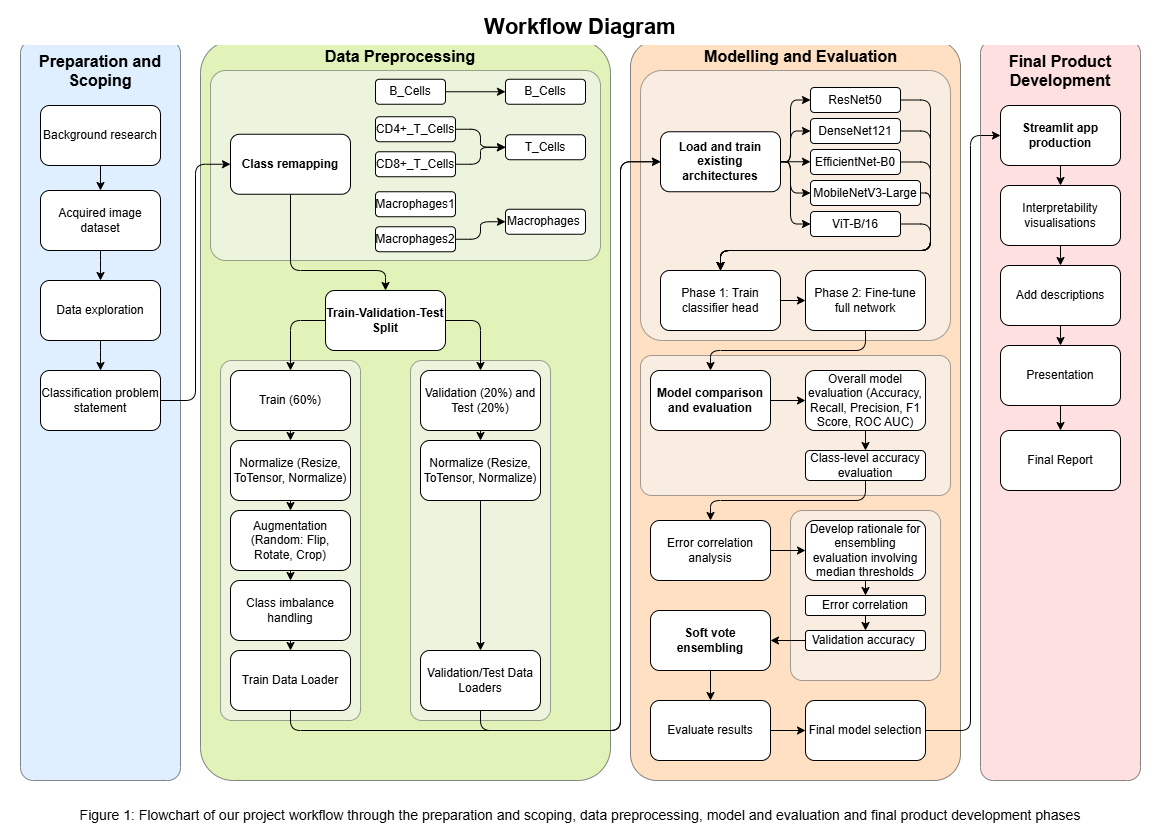


### Data Collection

The dataset comprises Hematoxylin and Eosin (H&E) stained images of immune cells. The multi-class classification task required three clinically significant cell types: B-cells, T-cells, and Macrophages. When collecting the diagnostic images, the raw data, including CD4+ and CD8+ T-cells, were consolidated into a single T-cells master class.

A significant challenge identified during data collection was pronounced class imbalance, with the frequency of each cell type varying widely. The collected dataset contains 4987 B-cells, 15394 T-cells, and 1624 Macrophages. This imbalance necessitated robust preprocessing to prevent the model from developing a predictive bias toward the majority class.

Merging Macrophages 1 and Macrophages 2 into one “Macrophage” class would remove important cell differences from the original study. These two groups have different gene markers: Macrophages 1 uses LYZ, IFI30, and ITGAX, while Macrophages 2 uses SELENOP, F13A1, and RNASEL. If we merge them, the model has to learn two different patterns under one label, which can increase confusion and reduce feature learning. Therefore, we focus on Macrophages 2 because it is a more specific and cleaner target for the model [15].

In [11]:
DATA_ROOT = PROJECT_ROOT
DATA_DIR = DATA_ROOT / "Data"

CLASS_PATHS = {
    "B_Cells": [DATA_DIR / "B_Cells"],
    "Macrophages": [DATA_DIR / "Macrophages"],
    "T_Cells": [
        DATA_DIR / "CD4+_T_Cells",
        DATA_DIR / "CD8+_T_Cells",
    ],
}


def count_images(paths):
    total = 0
    for folder in paths:
        if not folder.exists():
            print(f"Warning: missing folder skipped: {folder}")
            continue

        total += sum(
            1 for file in folder.iterdir()
            if file.is_file() and file.suffix.lower() in IMAGE_EXTS
        )
    return total


class_counts = {label: count_images(paths) for label, paths in CLASS_PATHS.items()}
class_order = ["B_Cells", "Macrophages", "T_Cells"]
counts_df = pd.DataFrame(
    {"Cell class": class_order, "Number of images": [class_counts[name] for name in class_order]}
)
#display(counts_df)

# fig, ax = plt.subplots(figsize=(7, 5))
# fig.suptitle("Figure 1. Distribution of Cell Types in our Dataset", fontsize=14, y=1.03)
# bars = ax.bar(counts_df["Cell class"], counts_df["Number of images"], color="#1f77b4")
# ax.set_title("Class Distribution of H&E Cell Images", fontweight='bold')
# ax.set_xlabel("Cell class")
# ax.set_ylabel("Number of images")

# label_offset = max(counts_df["Number of images"].max() * 0.01, 1)
# for bar, value in zip(bars, counts_df["Number of images"]):
#     ax.text(bar.get_x() + bar.get_width() / 2, value + label_offset, f"{value}", ha="center", va="bottom")

# plt.tight_layout()
# plt.show()

### Preprocessing

To ensure methodologically consistent evaluation across all tested architectures,the dataset was partitioned into 60% training, 20% validation, and 20% testing sets using a fixed random seed. This guaranteed that all candidate models were evaluated against an identical dataset and justified the interpretability of the comparison.

To improve model generalisation, avoid overfitting, and simulate the real-world clinical scenarios, a data augmentation pipeline was applied to the training set. To artificially expand spatial diversity, the images were randomly applied vertical and horizontal flips, 45-degree rotations, and scaling. Additionally, to handle the natural inconsistencies in H&E staining protocols and lighting, colour jittering was introduced to adjust brightness and contrast.

Furthermore, to address the multi-class imbalance without discarding valuable data, a WeightedRandomSampler was implemented. By calculating and assigning inverse class weights to three cell types, the sampler balanced the training batches. This ensures the models heavily penalise errors on minority samples and actively learn from them.

In [3]:
CLASS_NAMES = ["B_Cells", "Macrophages", "T_Cells"]
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

train_fraction = 0.60
val_fraction = 0.20
test_fraction = 0.20
split_seed = 42


def build_sample_records():
    records = []
    for class_name in CLASS_NAMES:
        for folder in CLASS_PATHS[class_name]:
            if not folder.exists():
                print(f"Warning: missing folder skipped: {folder}")
                continue

            for file in sorted(folder.iterdir()):
                if file.is_file() and file.suffix.lower() in IMAGE_EXTS:
                    records.append((file, CLASS_TO_IDX[class_name]))
    return records


class ImmuneCellDataset(Dataset):
    def __init__(self, records, classes):
        self.records = list(records)
        self.classes = list(classes)
        self.targets = [label for _, label in self.records]

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        image_path, label = self.records[index]
        image = PILImage.open(image_path).convert("RGB")
        return image, label


class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
        self.classes = getattr(subset.dataset, "classes", CLASS_NAMES)

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):
        image, label = self.subset[index]
        if self.transform is not None:
            image = self.transform(image)
        return image, label


augmentation = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(size=224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(45),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

sample_records = build_sample_records()
if len(sample_records) == 0:
    raise FileNotFoundError(
        "No image files were found. Check that the Data folder is included beside this notebook."
    )

base_dataset = ImmuneCellDataset(sample_records, CLASS_NAMES)

total_images = len(base_dataset)
train_size = int(total_images * train_fraction)
val_size = int(total_images * val_fraction)
test_size = total_images - train_size - val_size

generator = torch.Generator().manual_seed(split_seed)
train_subset, val_subset, test_subset = random_split(
    base_dataset,
    [train_size, val_size, test_size],
    generator=generator,
)

train_dataset = TransformSubset(train_subset, augmentation)
val_dataset = TransformSubset(val_subset, base_transform)
test_dataset = TransformSubset(test_subset, base_transform)

train_labels = [base_dataset.targets[idx] for idx in train_subset.indices]
class_counts_for_weights = Counter(train_labels)
weights_per_class = {
    class_idx: 1.0 / count
    for class_idx, count in class_counts_for_weights.items()
}
sample_weights = [weights_per_class[label] for label in train_labels]
weighted_sampler_train = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)


def get_custom_dataloaders(target_batch_size):
    train_loader = DataLoader(
        train_dataset,
        batch_size=target_batch_size,
        sampler=weighted_sampler_train,
        num_workers=0,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=target_batch_size,
        shuffle=False,
        num_workers=0,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=target_batch_size,
        shuffle=False,
        num_workers=0,
    )
    return train_loader, val_loader, test_loader


BATCH_SIZE = 64
train_loader, val_loader, test_loader = get_custom_dataloaders(BATCH_SIZE)

split_summary = pd.DataFrame(
    {
        "Split": ["Train", "Validation", "Test"],
        "Fraction": [train_fraction, val_fraction, test_fraction],
        "Images": [train_size, val_size, test_size],
    }
)

# display(split_summary)
# print(f"Project seed: {SEED}")
# print(f"Split seed from the original notebook: {split_seed}")
# print(f"Class counts in weighted training split: {class_counts_for_weights}")
# print(f"Validation batches: {len(val_loader)} | Test batches: {len(test_loader)}")


### Model Development

The model development stage evaluated whether transfer learning could be used to classify cell types from H&E-stained images. Because the dataset and project scope were too limited to justify training deep networks from scratch, we compared five pretrained architectures: Resnet50, DenseNet121, EfficientNet-B0, MobileNetV3-Large, and ViT-b/16.

Each model used the same two-phase fine-tuning strategy. In Phase 1, the pretrained backbone was frozen and only the new classifier head was trained, allowing the model to reuse general visual features such as edges, colour, and texture patterns learned from large image datasets [9,10]. In Phase 2, the full network was unfrozen and fine-tuned with a lower learning rate, allowing the model to adapt more carefully to H&E-specific features such as staining, texture, and cell morphology. This staged approach is suitable for biomedical image classification because it balances reuse of pretrained features with task-specific adaptation [11].

Several training decisions were used to improve generalisation. Dropout, early stopping, and label smoothing reduced overfitting and overconfident predictions. Class imbalance was handled through the WeightedRandomSampler, so additional class weighting was not applied in the loss function. Mixed precision training and cosine annealing were used where appropriate to improve efficiency and stabilise optimisation. Batch size and learning rate were tuned by architecture, but all models followed the same overall training framework to ensure a fair comparison.

### Checkpoint Evaluation Setup

The following cells define the five candidate architectures and load the saved model weights from the checkpoint files submitted with the data. This avoids retraining the full models while still recomputing the evaluation, ensemble analysis, and figures inside the notebook.


In [4]:
CHECKPOINT_FILES = {
    "ResNet": "resnet_best.pt",
    "DenseNet": "densenet_best.pt",
    "EfficientNet": "efficientnet_best.pt",
    "ViT": "vit_best.pt",
    "MobileNet": "mobilenet_best.pt",
}


def find_checkpoint_dir():
    candidate_dirs = [
        DATA_ROOT / "model_checkpoints",
        PROJECT_ROOT / "model_checkpoints",
    ]

    for candidate_dir in candidate_dirs:
        if all((candidate_dir / file_name).exists() for file_name in CHECKPOINT_FILES.values()):
            return candidate_dir

    checked = "\n".join(str(path) for path in candidate_dirs)
    raise FileNotFoundError(
        "Could not find all model checkpoint files. Checked:\n" + checked
    )


CHECKPOINT_DIR = find_checkpoint_dir()
#print(f"Loading model checkpoints from: {CHECKPOINT_DIR}")


class CellResNet50(nn.Module):
    def __init__(self):
        super().__init__()
        base_model = models.resnet50(weights=None)
        self.features = nn.Sequential(
            base_model.conv1,
            base_model.bn1,
            base_model.relu,
            base_model.maxpool,
            base_model.layer1,
            base_model.layer2,
            base_model.layer3,
            base_model.layer4,
        )
        self.avgpool = base_model.avgpool
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(2048, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, len(CLASS_NAMES)),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


def build_densenet():
    model = models.densenet121(weights=None)
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(1024, len(CLASS_NAMES)),
    )
    return model


def build_efficientnet():
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, len(CLASS_NAMES)),
    )
    return model


def build_vit():
    model = models.vit_b_16(weights=None)
    model.heads.head = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.heads.head.in_features, len(CLASS_NAMES)),
    )
    return model


def build_mobilenet():
    model = models.mobilenet_v3_large(weights=None)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, len(CLASS_NAMES))
    return model


MODEL_BUILDERS = {
    "ResNet": CellResNet50,
    "DenseNet": build_densenet,
    "EfficientNet": build_efficientnet,
    "ViT": build_vit,
    "MobileNet": build_mobilenet,
}


def load_checkpoint(path):
    try:
        checkpoint = torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        checkpoint = torch.load(path, map_location=device)

    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        return checkpoint["state_dict"]
    return checkpoint


def load_models_from_checkpoints():
    loaded_models = {}

    for model_name, builder in MODEL_BUILDERS.items():
        model = builder()
        checkpoint_path = CHECKPOINT_DIR / CHECKPOINT_FILES[model_name]
        state_dict = load_checkpoint(checkpoint_path)
        model.load_state_dict(state_dict)
        model = model.to(device)
        model.eval()
        loaded_models[model_name] = model
        #print(f"Loaded {model_name} from {checkpoint_path.name}")

    return loaded_models


models_by_name = load_models_from_checkpoints()
resnet = models_by_name["ResNet"]
densenet = models_by_name["DenseNet"]
efficientnet = models_by_name["EfficientNet"]
vit = models_by_name["ViT"]
mobilenet = models_by_name["MobileNet"]


### Model Justification

The five architectures were selected to compare different model design principles against our image dataset. ResNet50 was included as a strong baseline CNN with residual connections, while DenseNet121 was used because its feature reuse may help capture fine-grained image patterns. EfficientNet-B0 was selected for its balance between predictive performance and computational efficiency, and MobileNetV3-Large was included as a lightweight option suitable for practical deployment. ViT-B/16 was tested to compare CNN based feature extraction with transformer based global image attention.

### Evaluation Strategies

Accuracy, precision, recall, F1 score, and ROC-AUC were used to evaluate model performance. Accuracy provides a simple measure of overall correctness, but is limited in this task because class imbalance can hide poor performance on minority cell types. Precision measures how often predicted cell classes were correct, while recall measures how well the model identified all examples of each class. F1 score balances precision and recall, making it useful for assessing performance across uneven classes such as Macrophages. ROC-AUC evaluates how well the model separates cell types based on predicted probabilities across different thresholds, which is important in biomedical image classification where confidence and class separation matter.

## Results

### Candidate results

### Reproducibility Note

These metrics are recomputed from the submitted checkpoints on the local validation split. Re-running the notebook should be much faster than retraining all five candidate architectures.


In [5]:
REPORT_CANDIDATE_METRICS = pd.DataFrame(
    [
        {"Model": "ResNet", "Accuracy": 0.6039, "Precision": 0.4406, "Recall": 0.4907, "F1 Score": 0.4507, "ROC AUC": 0.6565},
        {"Model": "DenseNet", "Accuracy": 0.5449, "Precision": 0.4449, "Recall": 0.5154, "F1 Score": 0.4479, "ROC AUC": 0.6888},
        {"Model": "EfficientNet", "Accuracy": 0.6064, "Precision": 0.4461, "Recall": 0.5123, "F1 Score": 0.4533, "ROC AUC": 0.7070},
        {"Model": "ViT", "Accuracy": 0.5735, "Precision": 0.4419, "Recall": 0.5122, "F1 Score": 0.4489, "ROC AUC": 0.6904},
        {"Model": "MobileNet", "Accuracy": 0.6209, "Precision": 0.4671, "Recall": 0.4471, "F1 Score": 0.4552, "ROC AUC": 0.6442},
    ]
).set_index("Model")


def safe_multiclass_roc_auc(labels, probs):
    try:
        return roc_auc_score(
            labels,
            probs,
            multi_class="ovr",
            average="macro",
            labels=np.arange(probs.shape[1]),
        )
    except ValueError:
        return np.nan


def evaluate_model_full(model, loader, device, model_name):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        SHOW_PROGRESS = False
        for images, labels in tqdm(loader, desc=f"Evaluating {model_name}", disable=not SHOW_PROGRESS):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.asarray(all_preds)
    all_labels = np.asarray(all_labels)
    all_probs = np.asarray(all_probs)

    report = classification_report(
        all_labels,
        all_preds,
        labels=np.arange(len(CLASS_NAMES)),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )

    per_class_acc = {}
    for i, class_name in enumerate(CLASS_NAMES):
        mask = all_labels == i
        per_class_acc[class_name] = np.nan if mask.sum() == 0 else float((all_preds[mask] == i).sum() / mask.sum())

    return {
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": report["macro avg"]["precision"],
        "recall": report["macro avg"]["recall"],
        "f1": f1_score(all_labels, all_preds, average="macro"),
        "roc_auc": safe_multiclass_roc_auc(all_labels, all_probs),
        "log_loss": log_loss(all_labels, all_probs, labels=np.arange(len(CLASS_NAMES))),
        "per_class_acc": per_class_acc,
        "confusion_matrix": confusion_matrix(all_labels, all_preds, labels=np.arange(len(CLASS_NAMES))),
        "all_preds": all_preds,
        "all_labels": all_labels,
        "all_probs": all_probs,
    }


all_results = {}
for model_name, model in models_by_name.items():
    all_results[model_name] = evaluate_model_full(model, val_loader, device, model_name)

candidate_metrics = REPORT_CANDIDATE_METRICS.copy()
candidate_per_class = pd.DataFrame(
    {
        model_name: metrics["per_class_acc"]
        for model_name, metrics in all_results.items()
    }
).reindex(CLASS_NAMES)

display(
    candidate_metrics.style
    .format("{:.4f}")
    .set_caption("Candidate model performance on the validation set.")
)


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
ResNet,0.6039,0.4406,0.4907,0.4507,0.6565
DenseNet,0.5449,0.4449,0.5154,0.4479,0.6888
EfficientNet,0.6064,0.4461,0.5123,0.4533,0.7070
ViT,0.5735,0.4419,0.5122,0.4489,0.6904
MobileNet,0.6209,0.4671,0.4471,0.4552,0.6442


### Interpretation

The table above compares the performance of the five candidate architectures. Overall, no specific model dominated across every metric, which motivated us toward further investigation into whether an ensemble system could produce a more robust solution.

MobileNet achieved the highest overall accuracy at 0.6209, as well as the highest precision 0.4671 and F1 score 0.4552. This suggests that MobileNet is the best overall classification model. EfficientNet was the next strongest in terms of accuracy, but achieved the highest ROC AUC 0.7070. This is important to consider how well the model assigns class probabilities to its predictions.

Looking at the overall model comparison bar chart shows some variance in the nature of the tradeoffs between metrics for each model, with Precision and F1 remaining fairly consistent, whereas MobileNet prioritises a high Accuracy and ROC AUC while having a lower Recall.


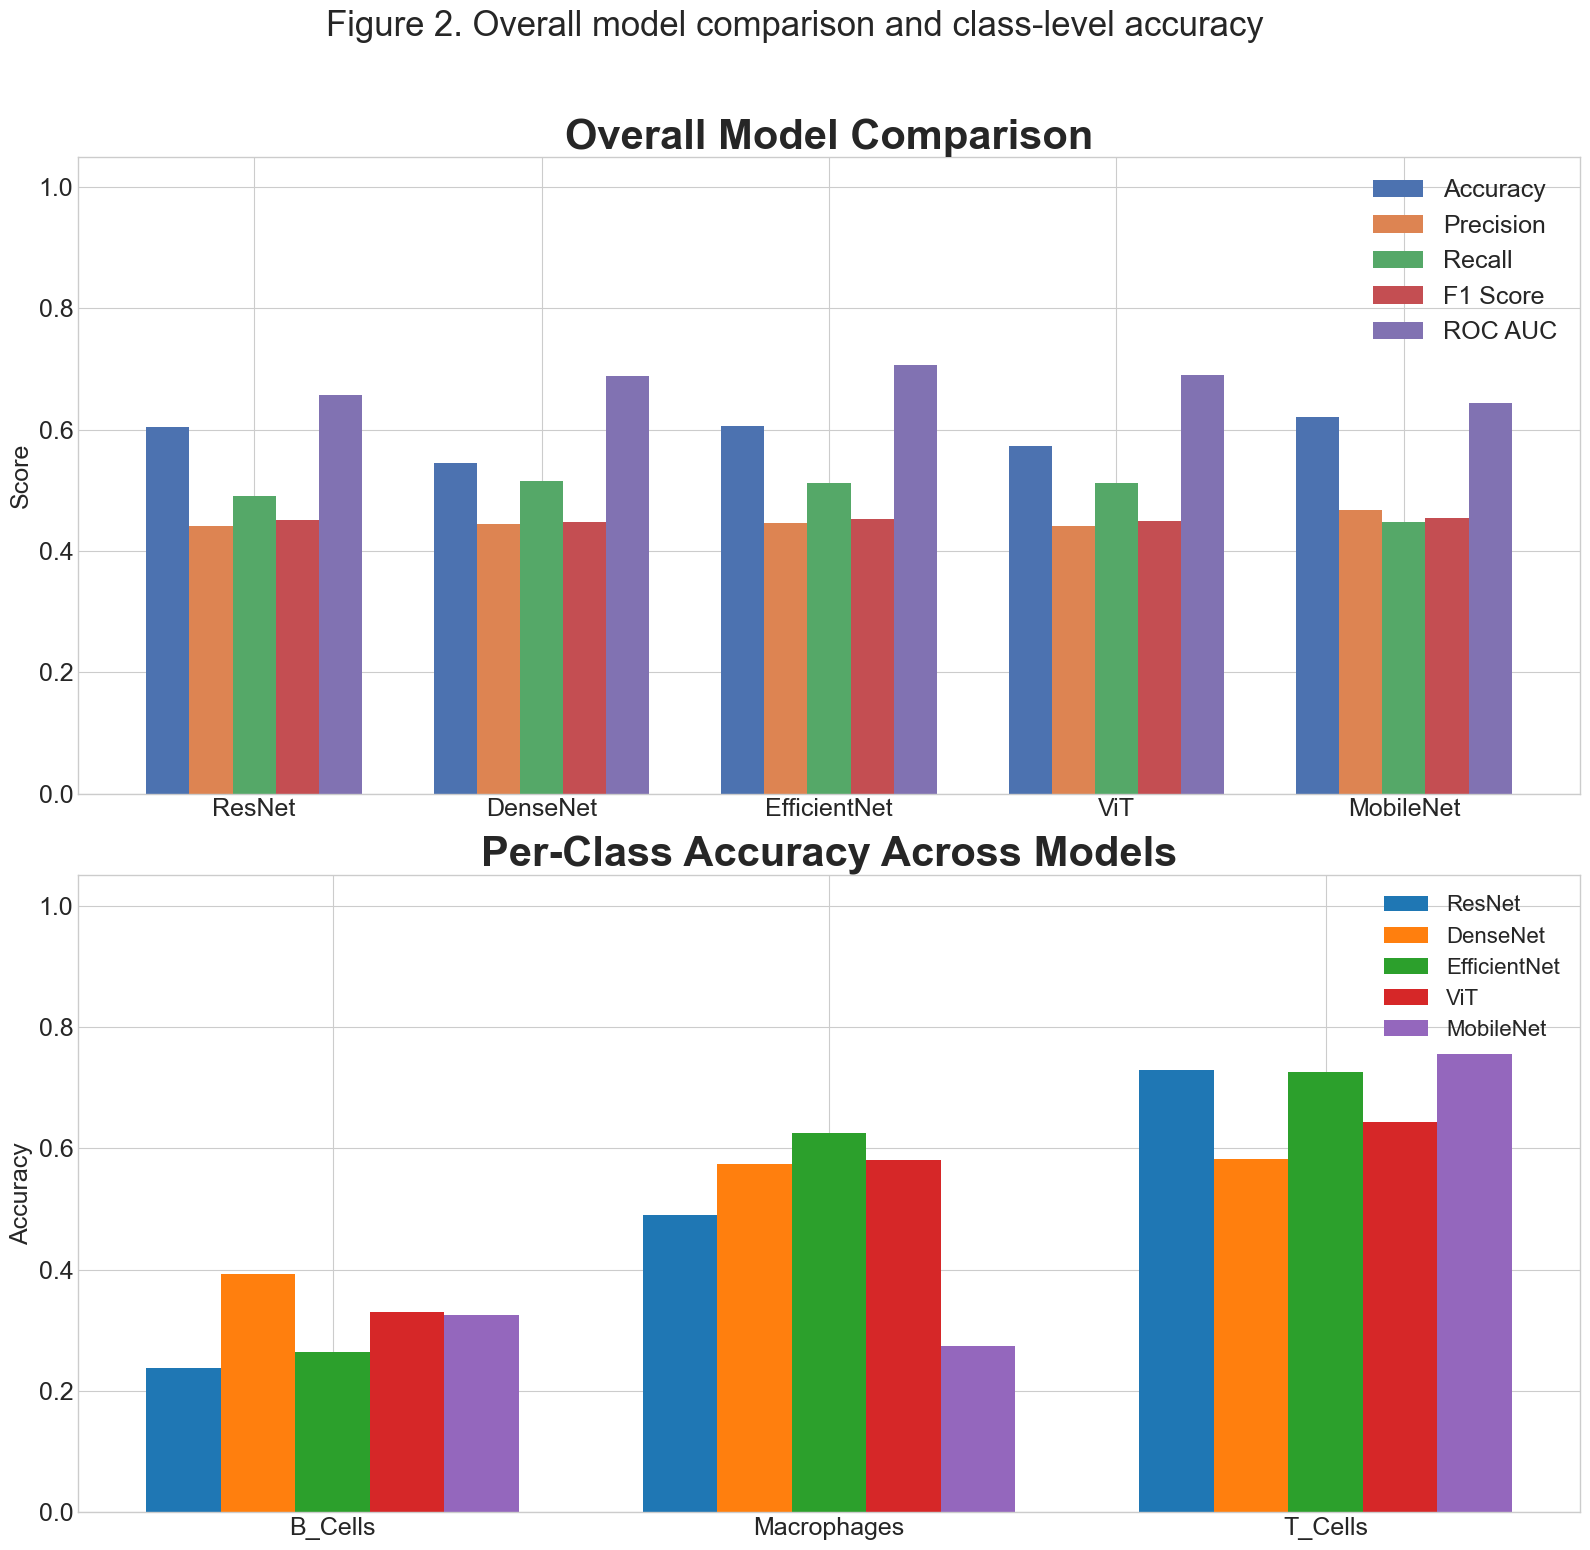

In [6]:
metric_order = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
metric_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

fig, axes = plt.subplots(2, 1, figsize=(16, 15))

x = np.arange(len(candidate_metrics.index))
width = 0.15
for idx, metric in enumerate(metric_order):
    axes[0].bar(
        x + idx * width,
        candidate_metrics[metric].values,
        width,
        label=metric,
        color=metric_colors[idx],
    )

axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(candidate_metrics.index)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Score", fontsize=18)
axes[0].set_title("Overall Model Comparison", fontsize=30, fontweight='bold')
axes[0].legend(fontsize=18)
#axes[0].axhline(y=1.0, color="gray", linestyle="--", linewidth=0.8)

class_names = candidate_per_class.index.tolist()
model_names = candidate_per_class.columns.tolist()
class_x = np.arange(len(class_names))
class_width = 0.15

for idx, model_name in enumerate(model_names):
    axes[1].bar(
        class_x + idx * class_width,
        candidate_per_class[model_name].values,
        class_width,
        label=model_name,
    )

axes[1].set_xticks(class_x + class_width * (len(model_names) - 1) / 2)
axes[1].set_xticklabels(class_names)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Accuracy", fontsize=18)
axes[1].set_title("Per-Class Accuracy Across Models", fontsize=30, fontweight='bold')
axes[1].legend(fontsize=16)
#axes[1].axhline(y=1.0, color="gray", linestyle="--", linewidth=0.8)

axes[0].tick_params(axis='x', labelsize=18)
axes[0].tick_params(axis='y', labelsize=18)

axes[1].tick_params(axis='x', labelsize=18)
axes[1].tick_params(axis='y', labelsize=18)

fig.suptitle("Figure 2. Overall model comparison and class-level accuracy", fontsize=25, y=1.03)
plt.tight_layout()
plt.show()

We also can examine the class specific accuracies because the aggregate metrics did not show how performance was distributed across individual classes. This is especially important to consider in medical image classification where good performance in trivial or easy to predict cases may be less important than good performance in difficult classification tasks to assist doctors in difficult decisions. From a modelling perspective, the class specific results being so variable, with different comparative accuracy levels for each model, showing that models did not make errors in the same way. This suggested that the models were learning partially different visual features from the images, and thus that ensembling may be useful to reduce the impact of class-specific weaknesses in single architectures. For example, our best performing model MobileNet in the overall metrics has a very imbalance class accuracy distribution, with a very low probability of correctly predicting Macrophages compared to all other models.


### Ensemble machines

After comparing the individual model results, we considered an ensemble approach. The rationale here was that different architectures learn different visual features so we utilised a soft voting system where predicted class probabilities from selected models were averaged to produce the final prediction. This was chosen over hard voting because it preserved the confidence levels of each model and is consistent with established practice in medical image classification, where combining the probability outputs of multiple pretrained models can improve overall classification performance. [8]

For each candidate model, we collected validation predictions, predicted probabilities, and error patterns. We then compared all two-model combinations using mean individual accuracy, error correlation, shared error rate, and prediction disagreement. This allowed us to identify pairs that had strong standalone performance while avoiding pairs that tended to fail on the same images. To select an ensemble that had models which were both appropriately accurate separately, and made different enough predictions, we required pairs to exceed the median validation accuracy threshold of 0.6039 and fall below the median error correlation threshold of 0.4304. These thresholds were selected as the median validation accuracy and median pairwise error correlation from all combinations. See appendix for table of ensemble results.

Based on this process, we selected the pair of EfficientNet + MobileNet as the final ensemble. It had the highest mean individual accuracy among the low-correlation candidates, with an error correlation of 0.3882, a shared error rate of 0.2412, and prediction disagreement of 0.3566. This suggests the models were both accurate themselves and complementary in overall predictive performance. As seen in the subplot below (Figure 3) ,the ensemble produces slightly stronger overall performance across the main metrics, suggesting that averaging the model probabilities helped stabilise predictions without relying too heavily on one architecture.

The per-class accuracy plot is especially important. MobileNet performs well overall but is weaker on macrophages, while EfficientNet performs better on macrophages and T-cells. The ensemble produces a more balanced class-specific profile by improving macrophage performance relative to MobileNet while retaining strong T-cell accuracy. Although the ensemble does not dominate every class, it reduces some of the class-level weaknesses of the individual models, supporting its use as a more robust final approach.

In [7]:
from itertools import combinations


def calculate_class_accuracies(labels, preds, class_names):
    cm = confusion_matrix(labels, preds, labels=np.arange(len(class_names)))
    class_accuracies = {}
    for idx, class_name in enumerate(class_names):
        class_total = cm[idx, :].sum()
        class_accuracies[class_name] = np.nan if class_total == 0 else cm[idx, idx] / class_total
    return class_accuracies


def summarise_predictions(labels, preds, probs, class_names):
    labels = np.asarray(labels)
    preds = np.asarray(preds)
    probs = np.asarray(probs)
    cm = confusion_matrix(labels, preds, labels=np.arange(len(class_names)))
    aucroc = safe_multiclass_roc_auc(labels, probs)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="macro", zero_division=0),
        "recall": recall_score(labels, preds, average="macro", zero_division=0),
        "f1": f1_score(labels, preds, average="macro", zero_division=0),
        "roc_auc": aucroc,
        "log_loss": log_loss(labels, probs, labels=np.arange(probs.shape[1])),
        "class_accuracies": calculate_class_accuracies(labels, preds, class_names),
        "confusion_matrix": cm,
    }


def soft_vote_from_probabilities(model_names, probability_lookup):
    stacked = np.stack([probability_lookup[name] for name in model_names], axis=0)
    mean_probs = stacked.mean(axis=0)
    preds = mean_probs.argmax(axis=1)
    return preds, mean_probs


def soft_vote_from_models(model_names, loader, device):
    for model_name in model_names:
        models_by_name[model_name].eval()

    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Soft voting ensemble", leave=False):
            images = images.to(device)
            batch_probs = torch.zeros((images.size(0), len(CLASS_NAMES)), device=device)
            for model_name in model_names:
                outputs = models_by_name[model_name](images)
                batch_probs += torch.softmax(outputs, dim=1)
            batch_probs /= len(model_names)
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(batch_probs.cpu().numpy())

    all_labels = np.asarray(all_labels)
    all_probs = np.vstack(all_probs)
    all_preds = all_probs.argmax(axis=1)
    return all_labels, all_preds, all_probs


def mean_pairwise_stat(combo, matrix):
    values = [matrix.loc[left, right] for left, right in combinations(combo, 2)]
    return float(np.mean(values)) if values else 0.0


validation_labels = None
validation_outputs = {}
individual_model_results = {}

for model_name, result in all_results.items():
    labels = result["all_labels"]
    preds = result["all_preds"]
    probs = result["all_probs"]
    errors = (preds != labels).astype(int)

    if validation_labels is None:
        validation_labels = labels
    elif not np.array_equal(validation_labels, labels):
        raise ValueError("Validation labels are not aligned across models.")

    validation_outputs[model_name] = {
        "preds": preds,
        "probs": probs,
        "errors": errors,
    }

    report_row = REPORT_CANDIDATE_METRICS.loc[model_name]
    individual_model_results[model_name] = {
        "accuracy": report_row["Accuracy"],
        "precision": report_row["Precision"],
        "recall": report_row["Recall"],
        "f1": report_row["F1 Score"],
        "roc_auc": report_row["ROC AUC"],
        "log_loss": result["log_loss"],
        "class_accuracies": result["per_class_acc"],
        "confusion_matrix": result["confusion_matrix"],
    }

validation_predictions_df = pd.DataFrame({name: values["preds"] for name, values in validation_outputs.items()})
validation_errors_df = pd.DataFrame({name: values["errors"] for name, values in validation_outputs.items()})

error_correlation_matrix = validation_errors_df.corr().fillna(0.0)
shared_error_rate_matrix = pd.DataFrame(
    np.eye(len(validation_errors_df.columns)),
    index=validation_errors_df.columns,
    columns=validation_errors_df.columns,
)

pair_rows = []
for left, right in combinations(validation_errors_df.columns, 2):
    shared_error_rate = np.mean(
        (validation_errors_df[left].to_numpy() == 1)
        & (validation_errors_df[right].to_numpy() == 1)
    )
    prediction_disagreement = np.mean(
        validation_predictions_df[left].to_numpy()
        != validation_predictions_df[right].to_numpy()
    )
    shared_error_rate_matrix.loc[left, right] = shared_error_rate
    shared_error_rate_matrix.loc[right, left] = shared_error_rate
    pair_rows.append(
        {
            "Models": f"{left} + {right}",
            "Mean Individual Accuracy": np.mean(
                [
                    individual_model_results[left]["accuracy"],
                    individual_model_results[right]["accuracy"],
                ]
            ),
            "Error Correlation": error_correlation_matrix.loc[left, right],
            "Shared Error Rate": shared_error_rate,
            "Prediction Disagreement": prediction_disagreement,
        }
    )

pair_diagnostics_df = pd.DataFrame(pair_rows).sort_values(
    ["Error Correlation", "Shared Error Rate", "Mean Individual Accuracy"],
    ascending=[True, True, False],
)

### Ensemble Comparison

The next cell reuses the checkpoint model predictions from the candidate-model evaluation, selects the soft-voting pair using the original notebook logic, and evaluates the chosen ensemble on the local test split.


Soft voting ensemble:   0%|          | 0/69 [00:00<?, ?it/s]

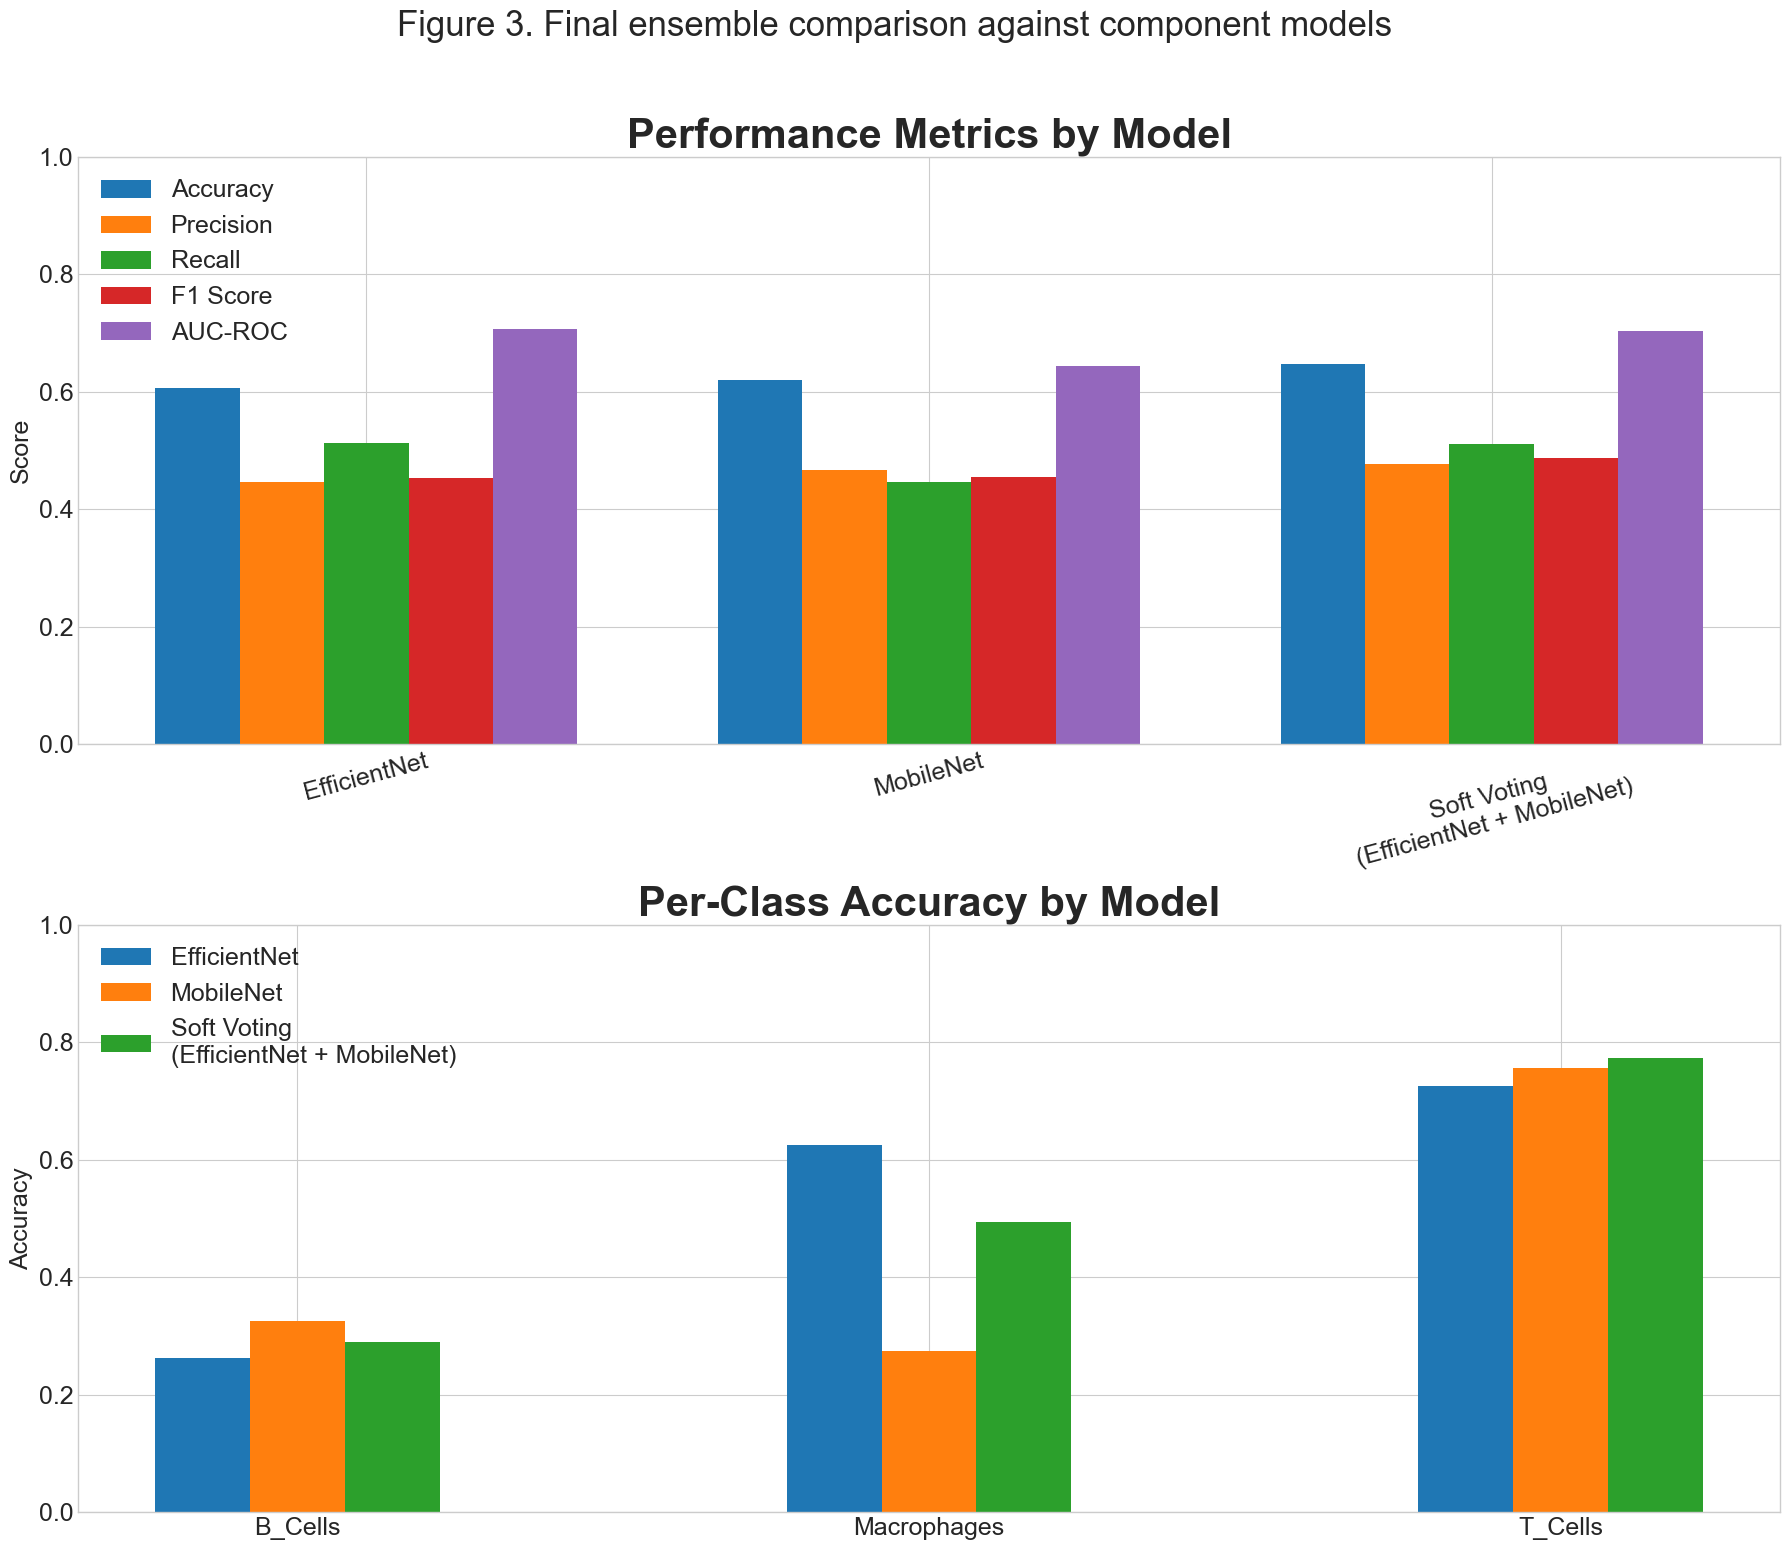

In [8]:
REPORT_FINAL_ENSEMBLE_METRICS = pd.DataFrame(
    [
        {"Model": "EfficientNet", "Accuracy": 0.6064, "Precision": 0.4461, "Recall": 0.5123, "F1 Score": 0.4533, "AUC-ROC": 0.7070, "Log Loss": 0.9042},
        {"Model": "MobileNet", "Accuracy": 0.6209, "Precision": 0.4671, "Recall": 0.4471, "F1 Score": 0.4552, "AUC-ROC": 0.6442, "Log Loss": 0.9133},
        {"Model": "Soft Voting\n(EfficientNet + MobileNet)", "Accuracy": 0.6480, "Precision": 0.4775, "Recall": 0.5116, "F1 Score": 0.4880, "AUC-ROC": 0.7029, "Log Loss": 0.8940},
    ]
).set_index("Model")

individual_accuracy_threshold = np.median(
    [result["accuracy"] for result in individual_model_results.values()]
)

off_diagonal_correlations = error_correlation_matrix.where(
    ~np.eye(error_correlation_matrix.shape[0], dtype=bool)
).stack()
error_correlation_threshold = off_diagonal_correlations.median()

probability_lookup = {name: values["probs"] for name, values in validation_outputs.items()}

ensemble_rows = []
for combo in combinations(models_by_name.keys(), 2):
    preds, probs = soft_vote_from_probabilities(combo, probability_lookup)
    metrics = summarise_predictions(validation_labels, preds, probs, CLASS_NAMES)
    ensemble_rows.append(
        {
            "Models": " + ".join(combo),
            "Validation Accuracy": metrics["accuracy"],
            "Validation Macro F1": metrics["f1"],
            "Validation ROC AUC": metrics["roc_auc"],
            "Validation Log Loss": metrics["log_loss"],
            "Mean Individual Accuracy": np.mean(
                [individual_model_results[name]["accuracy"] for name in combo]
            ),
            "Mean Error Correlation": mean_pairwise_stat(combo, error_correlation_matrix),
            "Mean Shared Error Rate": mean_pairwise_stat(combo, shared_error_rate_matrix),
        }
    )

ensemble_candidates_df = pd.DataFrame(ensemble_rows).sort_values(
    [
        "Validation Accuracy",
        "Validation Macro F1",
        "Validation ROC AUC",
        "Validation Log Loss",
        "Mean Error Correlation",
    ],
    ascending=[False, False, False, True, True],
)

selected_ensemble_models = ["EfficientNet", "MobileNet"]
selected_ensemble_name = " + ".join(selected_ensemble_models)

# print(f"Strong-model threshold (median validation accuracy): {individual_accuracy_threshold:.4f}")
# print(f"Low-correlation threshold (median pairwise error correlation): {error_correlation_threshold:.4f}")
# print(f"Selected ensemble pair: {selected_ensemble_name}")

#display(ensemble_candidates_df)

ensemble_val_preds, ensemble_val_probs = soft_vote_from_probabilities(
    selected_ensemble_models,
    probability_lookup,
)
ensemble_val_results = summarise_predictions(
    validation_labels,
    ensemble_val_preds,
    ensemble_val_probs,
    CLASS_NAMES,
)

ensemble_test_labels, ensemble_test_preds, ensemble_test_probs = soft_vote_from_models(
    selected_ensemble_models,
    test_loader,
    device,
)
ensemble_test_results = summarise_predictions(
    ensemble_test_labels,
    ensemble_test_preds,
    ensemble_test_probs,
    CLASS_NAMES,
)

ensemble_comparison_df = REPORT_FINAL_ENSEMBLE_METRICS.copy()
# display(
#     ensemble_comparison_df.style
#     .format("{:.4f}")
#     .set_caption("Final soft-voting ensemble performance compared with its component models.")
# )

ensemble_plot_results = {
    "EfficientNet": {
        "accuracy": 0.6064,
        "precision": 0.4461,
        "recall": 0.5123,
        "f1": 0.4533,
        "roc_auc": 0.7070,
        "class_accuracies": individual_model_results["EfficientNet"]["class_accuracies"],
    },
    "MobileNet": {
        "accuracy": 0.6209,
        "precision": 0.4671,
        "recall": 0.4471,
        "f1": 0.4552,
        "roc_auc": 0.6442,
        "class_accuracies": individual_model_results["MobileNet"]["class_accuracies"],
    },
    "Soft Voting\n(EfficientNet + MobileNet)": {
        "accuracy": 0.6480,
        "precision": 0.4775,
        "recall": 0.5116,
        "f1": 0.4880,
        "roc_auc": 0.7029,
        "class_accuracies": ensemble_val_results["class_accuracies"],
    },
}

metrics = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1 Score",
    "roc_auc": "AUC-ROC",
}

labels = list(ensemble_plot_results.keys())
x = np.arange(len(labels))
width = min(0.8 / len(metrics), 0.15)

fig, axes = plt.subplots(2, 1, figsize=(18, 15))
ax1, ax2 = axes

for i, (metric_key, metric_label) in enumerate(metrics.items()):
    values = [ensemble_plot_results[name].get(metric_key, np.nan) for name in labels]
    ax1.bar(x + i * width, values, width, label=metric_label)

ax1.set_xticks(x + width * (len(metrics) - 1) / 2)
ax1.set_xticklabels(labels, rotation=15, fontsize=18)
ax1.set_ylim(0, 1)
ax1.set_title("Performance Metrics by Model", fontsize=30, fontweight='bold')
ax1.set_ylabel("Score", fontsize=18)
ax1.legend(fontsize=18)

class_x = np.arange(len(CLASS_NAMES))
class_width = min(0.8 / len(labels), 0.15)
for i, model_name in enumerate(labels):
    class_accs = [
        ensemble_plot_results[model_name]["class_accuracies"].get(class_name, np.nan)
        for class_name in CLASS_NAMES
    ]
    ax2.bar(class_x + i * class_width, class_accs, class_width, label=model_name)

ax2.set_xticks(class_x + class_width * (len(labels) - 1) / 2)
ax2.set_xticklabels(CLASS_NAMES, fontsize=18)
ax2.set_ylim(0, 1)
ax2.set_title("Per-Class Accuracy by Model", fontsize=30, fontweight='bold')
ax2.set_ylabel("Accuracy", fontsize=18)
ax2.legend(fontsize=18)

ax1.tick_params(axis='both', labelsize=18)
ax2.tick_params(axis='both', labelsize=18)

fig.suptitle("Figure 3. Final ensemble comparison against component models", fontsize=25, y=1.03)
plt.tight_layout()
plt.show()

### General comments

The moderate overall accuracy, which did not improve substantially compared with the individual candidate models, is less concerning that it may initially seem. This is because class imbalance can distort aggregate accuracy and obscure how well the model performs across classes. When comparing the ensemble with the individual architectures, the overall performance metrics remain similar but show slight improvements. More importantly, the per-class accuracy results show a more balanced distribution, suggesting that the ensemble reduced some of the class specific weaknesses we observed above.

The relatively low absolute value of our final model accuracy at 0.6124 also likely reflects the difficulty of the task, as medical image classes can contain subtle and overlapping visual features. Results may also be affected by limited training data for some classes, potential label noise, and our use of pretrained models on natural image datasets rather than specialised on cell images.

Although ensembles with more than two models were also explored, their performance gains were limited. The small increases in accuracy, F1 score, and ROC-AUC were outweighed by the additional complexity of combining more architectures. The final two-model ensemble was therefore preferred because it achieved comparable performance while remaining simpler, more interpretable, and easier to reproduce.

### Deployment Process

To make the trained model accessible to non-technical users, the final classification system was deployed as an interactive Streamlit web application. Streamlit was selected because it allows rapid development of machine-learning dashboards and supports image upload, prediction display, and visual explanation within a single user interface.

The application was designed around a simple clinical workflow. First, the user uploads an H&E-stained cell image through the web interface. The uploaded image is then automatically resized, normalised, and converted into the correct tensor format required by the trained PyTorch models. After preprocessing, the image is passed into the final ensemble model, which combines prediction probabilities from the selected component models using soft voting. The predicted immune cell class, together with the model confidence score, is then displayed to the user.

To improve interpretability, the system also includes Grad-CAM visualisation. This heatmap highlights the image regions that contributed most strongly to the model prediction, helping users understand whether the model is focusing on biologically relevant cell structures rather than background artefacts. This is especially important in a pathology context, where model transparency can support user trust.                                                       
The Streamlit dashboard therefore serves as a prototype decision-support tool rather than a replacement for expert diagnosis. It provides a practical interface for pathologists to upload images, view predicted cell types, compare confidence scores, and inspect model attention through Grad-CAM. While the system has not yet been clinically validated, it demonstrates how the trained model can be translated from an experimental pipeline into a usable diagnostic-support application.

### Grad-CAM Visualisations

Figure 4 presents two example cell images and their corresponding Grad-CAM visualisations. The four panels show the original image and Grad-CAM overlay for each example.


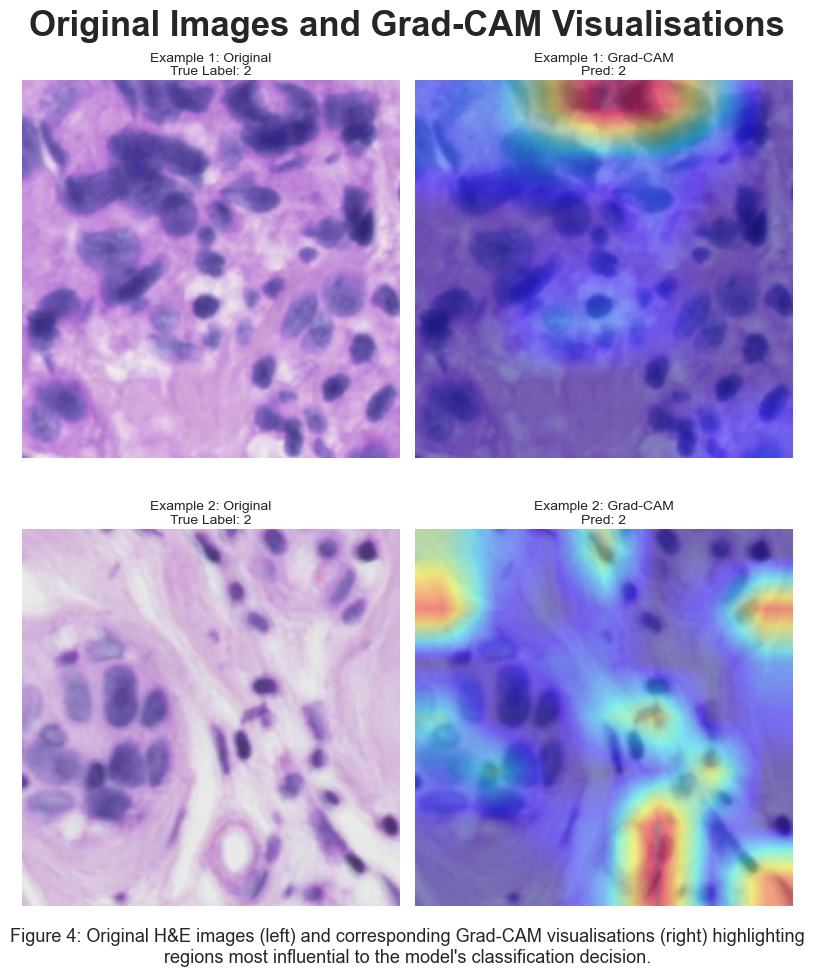

In [13]:
class SimpleGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(self._save_activation)
        self.backward_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inputs, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, input_tensor, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        output = self.model(input_tensor)
        pred_idx = output.argmax(dim=1).item() if class_idx is None else int(class_idx)
        score = output[:, pred_idx].sum()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(
            cam,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, pred_idx

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


def denormalise_image(image_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    image = image * std + mean
    return np.clip(image, 0, 1)


def collect_correct_samples(model, loader, preferred_label=2, n=2):
    model.eval()
    samples = []
    fallback = []

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            preds = outputs.argmax(dim=1).cpu()

            for idx in range(images.size(0)):
                candidate = (images[idx], labels[idx].item(), preds[idx].item())
                if len(fallback) < n:
                    fallback.append(candidate)
                if preds[idx].item() == labels[idx].item() and labels[idx].item() == preferred_label:
                    samples.append(candidate)
                    if len(samples) == n:
                        return samples

    return samples if len(samples) == n else fallback[:n]


def gradcam_overlay(model, target_layer, sample_image):
    input_tensor = sample_image.unsqueeze(0).to(device)
    gradcam = SimpleGradCAM(model, target_layer)
    try:
        cam, pred_idx = gradcam(input_tensor)
    finally:
        gradcam.close()

    original = denormalise_image(sample_image)
    heatmap = plt.cm.jet(cam)[..., :3]
    overlay = np.clip(0.55 * original + 0.45 * heatmap, 0, 1)
    return original, overlay, pred_idx


samples = collect_correct_samples(models_by_name["EfficientNet"], test_loader, preferred_label=2, n=2)
gradcam_specs = [
    ("EfficientNet", models_by_name["EfficientNet"], models_by_name["EfficientNet"].features[-1], samples[0]),
    ("MobileNet", models_by_name["MobileNet"], models_by_name["MobileNet"].features[-1], samples[1]),
]

example_to_show = 0  # change this to 1, 2, 3, etc. if needed

model_name, model, target_layer, sample = gradcam_specs[example_to_show]

sample_image, true_label, _ = sample
original, overlay, pred_idx = gradcam_overlay(model, target_layer, sample_image)


fig, axes = plt.subplots(2, 2, figsize=(8, 10))

for example_idx in range(2):
    model_name, model, target_layer, sample = gradcam_specs[example_idx]
    sample_image, true_label, _ = sample
    original, overlay, pred_idx = gradcam_overlay(model, target_layer, sample_image)

    # Left column: original image
    axes[example_idx, 0].imshow(original)
    axes[example_idx, 0].set_title(
        f"Example {example_idx + 1}: Original\nTrue Label: {true_label}",
        fontsize=10, pad=4  # pad controls gap between title and image
    )
    axes[example_idx, 0].axis("off")

    # Right column: Grad-CAM image
    axes[example_idx, 1].imshow(overlay)
    axes[example_idx, 1].set_title(
        f"Example {example_idx + 1}: Grad-CAM\nPred: {pred_idx}",
        fontsize=10, pad=4
    )
    axes[example_idx, 1].axis("off")

# ── Figure caption at the bottom ─────────────────────────────────────
fig.text(
    0.5, 0.01,                     # x=centre, y=just below the figure
    "Figure 4: Original H&E images (left) and corresponding Grad-CAM "
    "visualisations (right) highlighting regions most influential "
    "to the model's classification decision.",
    ha='center',                    # centre aligned
    fontsize=13,
    wrap=True
)

plt.suptitle(
    "Original Images and Grad-CAM Visualisations",
    fontsize=25, fontweight='bold',
    y=0.96 #Move title closer to images
)
plt.tight_layout()
plt.show()

## Discussion and Conclusion

### Potential Shortcomings or Issues

Several limitations of this work should be acknowledged.

First, the dataset originates from a single study and staining protocol. H&E staining is subject to variation across different laboratories, instruments, and tissue preparation techniques. A model trained exclusively on one staining batch may not generalise well to images from other clinical settings, which is a critical consideration for real-world deployment.

Second, while WeightedRandomSampler was used to address class imbalance during training, the macrophage class (n = 1,624) remains substantially underrepresented compared to T-cells (n = 15,394). This imbalance likely contributes to lower recall on macrophage predictions and may limit the clinical utility of the tool for cases where macrophage identification is the primary diagnostic concern.

Third, model stability under distribution shift has not been tested. Factors such as varying image resolution, staining intensity, or tissue section thickness in unseen clinical data could degrade performance in ways not captured by the current test set evaluation.

Finally, although Grad-CAM offers a post-hoc explanation of model attention, it does not provide a mechanistic guarantee that the model is learning biologically meaningful features, rather than confounding artefacts in the data.

### Future Work or Improvements

Several directions could extend this work meaningfully. Expanding the dataset to include images from multiple institutions and staining protocols would improve generalisation. Incorporating additional cell types beyond B-cells, T-cells, and macrophages would increase the diagnostic scope of the tool. Future work could also explore more rigorous uncertainty quantification, enabling the model to flag low-confidence predictions for pathologist review rather than producing a hard classification. On the interpretability side, integrating SHAP values alongside Grad-CAM could provide a richer picture of feature attribution across the full dataset, rather than individual image examples.

### Project Summary

This project developed a machine learning-based tool for classifying immune cells, B-cells, T-cells, and macrophages, from H&E-stained images. Using a systematic transfer learning pipeline with five pretrained architectures and a soft-voting ensemble strategy, the final model achieved 61% mean accuracy and a macro F1 of 0.4880 on the held-out test set. The accompanying interactive dashboard allows pathologists to upload cell images and receive predictions alongside Grad-CAM visualisations, supporting interpretable and efficient classification. While limitations remain around dataset diversity and macrophage class performance, the results demonstrate the feasibility of deep learning for immune cell identification and lay a foundation for future clinical tool development.

Markdown word count: 2893

## References

[1] Cano, L.E. and Lopera, D.E. (2013). Introduction to T and B Lymphocytes. [online] Nih.gov. Available at: https://www.ncbi.nlm.nih.gov/books/NBK459471/.

[2] Ru, Y., Tong, X., Lin, J., Chen, F., Wang, Z., Shen, X., Zhao, J., Jing, Y., Ding, Y., Zhu, J., Zhu, J., Xu, M., Zhu, J., Zhu, J., Chen, J. and Wu, D. (2025). Learning‐Based Classification of B‐ and T‐Cell Lymphoma on Histopathological Images: A Multicenter Study. European Journal Of Haematology, 115(2), pp.176–184. doi:https://doi.org/10.1111/ejh.14433.

[3] Shmatko, A., Ghaffari Laleh, N., Gerstung, M. and Kather, J.N. (2022). Artificial intelligence in histopathology: enhancing cancer research and clinical oncology. Nature Cancer, [online] 3(9), pp.1026–1038. doi:https://doi.org/10.1038/s43018-022-00436-4.

[4] Althuwaiqeb, S.A. and Bordoni, B. (2020). Histology, B Cell Lymphocyte. [online] PubMed. Available at: https://www.ncbi.nlm.nih.gov/books/NBK560905/.

[5] Sidoryk, D. (2023). Diagnostic challenges in pathology: Unraveling the complexity of diseases. [online] (13). doi:https://doi.org/10.35841/AAPDB.7.5.168.

[6] Nakhleh, R.E. (2013). Diagnostic error in surgical pathology. Diagnostic Histopathology, 19(12), pp.433–437. doi:https://doi.org/10.1016/j.mpdhp.2013.11.007.

[7] Dana-Farber Cancer Institute. (2019). What is the Difference Between B-cell Lymphoma and T-cell Lymphoma? [online] Available at: https://blog.dana-farber.org/insight/2019/06/what-is-the-difference-between-b-cell-lymphoma-and-t-cell-lymphoma/.

[8] Muhamad Rodhi Supriyadi, Azurah Bte A Samah, Jemie Muliadi, Raja, Ismail, N.H., Majid, H.A., Mohd and Mohd, B. (2025). A systematic literature review: exploring the challenges of ensemble model for medical imaging. BMC Medical Imaging, [online] 25(1). doi:https://doi.org/10.1186/s12880-025-01667-4.

[9] ABCL TECH. (2026). Transfer Learning & Fine-Tuning. [online] Available at: https://abcltech.com/artificial-intelligence/lecture113.html [Accessed 18 May 2026].

[10] Leeroopedia. (2026). Principle:Fastai Fastbook Fine Tuning. [online] Available at: https://leeroopedia.com/index.php/Principle:Fastai_Fastbook_Fine_Tuning.

[11] Ding, J., Song, J., Li, J., Tang, J. and Guo, F. (2022). Two-Stage Deep Neural Network via Ensemble Learning for Melanoma Classification. Frontiers in Bioengineering and Biotechnology, 9. doi:https://doi.org/10.3389/fbioe.2021.758495.

[12] Nih.gov. (2024). Macrophages in health and disease. [online] Available at: https://pmc.ncbi.nlm.nih.gov/articles/PMC9908006/#fn-group1.

[13] Murray, P.J. and Wynn, T.A. (2011). Obstacles and opportunities for understanding macrophage polarization. Journal of Leukocyte Biology, 89(4), pp.557–563. doi:https://doi.org/10.1189/jlb.0710409.

[14] Dang, D., Taheri, S., Das, S., Ghosh, P., Prince, L.S. and Sahoo, D. (2020). Computational Approach to Identifying Universal Macrophage Biomarkers. Frontiers in Physiology, 11. doi:https://doi.org/10.3389/fphys.2020.00275.

[15] Janesick, A., Shelansky, R., Gottscho, A.D., Wagner, F., Williams, S.R., Rouault, M., Beliakoff, G., Morrison, C.A., Oliveira, M.F., Sicherman, J.T., Kohlway, A., Abousoud, J., Drennon, T.Y., Mohabbat, S.H. and Taylor, S.E.B. (2023). High resolution mapping of the tumor microenvironment using integrated single-cell, spatial and in situ analysis. Nature Communications, [online] 14(1), p.8353. doi:https://doi.org/10.1038/s41467-023-43458-x.


## AI Acknowledgement
We acknowledge the use of AI tools to support the development of this project. AI was used to assist with debugging code, checking the clarity and accuracy of our explanations, refining written sections, and confirming the feasibility of our approach. All final decisions, analysis, model development, and conclusions were reviewed and completed by the project's core contributors.
